# Notebook for experimenting with MLP infrastructure for training

In [1]:
import pandas as pd
import numpy as np
import sklearn

In [2]:
pbp_all = pd.read_csv("data/pbp_all.csv")

def add_score_time_pressure(df: pd.DataFrame) -> pd.DataFrame:
    """tanh(scoreDif / (secondsLeft + 1)): margin weighted by time remaining."""
    out = df.copy()
    out["scoreTimePressure"] = np.tanh(
        out["scoreDif"].to_numpy(dtype=np.float64)
        / (out["secondsLeft"].to_numpy(dtype=np.float64) + 1.0)
    )
    return out

pbp_all = add_score_time_pressure(pbp_all)

train_df = pbp_all[pbp_all["season"].isin(["2021-22", "2022-23", "2023-24"])]
val_df = pbp_all[pbp_all["season"] == "2024-25"]
test_df = pbp_all[pbp_all["season"] == "2025-26"]

In [3]:
# display max columns none
pd.set_option('display.max_columns', None)

In [4]:
train_df.head()

,season,gameId,gameDate,matchup,homeTeamId,homeAbbreviation,awayTeamId,awayAbbreviation,homeWin,description,quarter,periodSecondsLeft,secondsLeft,scoreHome,scoreAway,scoreDif,pointsTotal,actionTeamSide,possession,actionType,line,homeFouls,awayFouls,homeBonus,awayBonus,homeFreeThrows,awayFreeThrows,homeEjections,awayEjections,scoreTimePressure
0,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,Period Start,Q1,720.0,2880.0,0.0,0.0,0.0,0.0,NaN,0.5,period,1.5,0,0,0,0,0,0,0,0,0.0
1,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,Jump Ball B. Lopez vs. N. Claxton: Tip to G. A...,Q1,715.0,2875.0,0.0,0.0,0.0,0.0,home,1.0,jumpball,1.5,0,0,0,0,0,0,0,0,0.0
2,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,MISS G. Allen 26' 3PT,Q1,702.0,2862.0,0.0,0.0,0.0,0.0,home,0.3,3pt,1.5,0,0,0,0,0,0,0,0,0.0
3,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,K. Durant REBOUND (Off:0 Def:1),Q1,699.0,2859.0,0.0,0.0,0.0,0.0,away,0.0,rebound,1.5,0,0,0,0,0,0,0,0,0.0
4,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,G. Antetokounmpo shooting personal FOUL (1 PF)...,Q1,687.0,2847.0,0.0,0.0,0.0,0.0,home,0.0,foul,1.5,1,0,0,0,0,2,0,0,0.0


In [5]:
numeric_features = [
    "periodSecondsLeft",
    "secondsLeft",
    "scoreDif",
    "pointsTotal",
    "possession",
    "homeFouls",
    "awayFouls",
    "homeBonus",
    "awayBonus",
    "homeFreeThrows",
    "awayFreeThrows",
    "homeEjections",
    "awayEjections",
    "line",
    "scoreTimePressure"
]

one_hot_features = [
    "quarter"
]

target = [
    "homeWin"
]

In [6]:
_required = numeric_features + one_hot_features + target
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    n = df[_required].isna().any(axis=1).sum()
    print(name, int(n))
print("total", int(
    train_df[_required].isna().any(axis=1).sum()
    + val_df[_required].isna().any(axis=1).sum()
    + test_df[_required].isna().any(axis=1).sum()
))

train 37187
val 0
test 10908
total 48095


In [7]:
# Snapshot of rows with NaN in any model column (run before preprocessing / dropna)
from IPython.display import display

_required = numeric_features + one_hot_features + target

_nan_parts = []
for split_name, df in (("train", train_df), ("val", val_df), ("test", test_df)):
    m = df[_required].isna().any(axis=1)
    if m.any():
        _nan_parts.append(df.loc[m].assign(_split=split_name))

if not _nan_parts:
    print("No NaN values in model columns for train / val / test.")
else:
    nan_rows = pd.concat(_nan_parts)

    def _missing_cols(row):
        return [c for c in _required if pd.isna(row[c])]

    snap = nan_rows.assign(missing_columns=nan_rows.apply(_missing_cols, axis=1))

    # Which columns are missing most often?
    miss_series = snap["missing_columns"].explode()
    print("NaN counts by column (among rows with any NaN):")
    display(miss_series.value_counts().sort_values(ascending=False))

    context = [c for c in ("season", "gameId", "description") if c in snap.columns]
    show_cols = context + _required + ["missing_columns", "_split"]
    show_cols = [c for c in show_cols if c in snap.columns]

    out = snap[show_cols].copy()
    if "description" in out.columns:
        out["description"] = out["description"].astype(str).str.slice(0, 80)

    print(f"\nSample of rows (total with any NaN: {len(snap):,}):")
    display(out.head(5))

NaN counts by column (among rows with any NaN):


missing_columns
line          48093
possession        2
Name: count, dtype: int64


Sample of rows (total with any NaN: 48,095):


,season,gameId,description,periodSecondsLeft,secondsLeft,scoreDif,pointsTotal,possession,homeFouls,awayFouls,homeBonus,awayBonus,homeFreeThrows,awayFreeThrows,homeEjections,awayEjections,line,scoreTimePressure,quarter,homeWin,missing_columns,_split
231168,2021-22,22100529,Period Start,720.0,2880.0,0.0,0.0,0.5,0,0,0,0,0,0,0,0,NaN,0.000000,Q1,1,[line],train
231169,2021-22,22100529,Jump Ball R. Williams III vs. J. Smith: Tip to...,716.0,2876.0,0.0,0.0,1.0,0,0,0,0,0,0,0,0,NaN,0.000000,Q1,1,[line],train
231170,2021-22,22100529,M. Smart cutting finger roll Layup (2 PTS) (R....,706.0,2866.0,2.0,2.0,0.0,0,0,0,0,0,0,0,0,NaN,0.000698,Q1,1,[line],train
231171,2021-22,22100529,J. Smith 19' Jump Shot (2 PTS) (M. Bridges 1 AST),689.0,2849.0,0.0,4.0,1.0,0,0,0,0,0,0,0,0,NaN,0.000000,Q1,1,[line],train
231172,2021-22,22100529,M. Smart 19' pullup Jump Shot (4 PTS) (A. Horf...,664.0,2824.0,2.0,6.0,0.0,0,0,0,0,0,0,0,0,NaN,0.000708,Q1,1,[line],train


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

# Rows with NaN in any model input or target produce NaN features after scaling,
# which leads to NaN network outputs and BCELoss failing its [0, 1] check.
_required = numeric_features + one_hot_features + target
feature_cols = numeric_features + one_hot_features


def _drop_nan_rows(df, name):
    n = len(df)
    out = df.dropna(subset=_required).copy()
    print(f"{name}: dropped {n - len(out):,} rows with NaN in model columns ({len(out):,} remaining)")
    return out


train_df = _drop_nan_rows(train_df, "train")
val_df = _drop_nan_rows(val_df, "val")
test_df = _drop_nan_rows(test_df, "test")

# Fitted on train only; transform val/test with train statistics (share this object later)
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False), one_hot_features),
    ],
)

feature_pipeline = Pipeline([("preprocess", preprocess)])
feature_pipeline.fit(train_df[feature_cols])

splits = (("train", train_df), ("val", val_df), ("test", test_df))
X_splits, y_splits = {}, {}
for name, df in splits:
    X_splits[name] = feature_pipeline.transform(df[feature_cols]).astype(np.float32)
    y_splits[name] = df[target].values.astype(np.float32)

X_train, X_val, X_test = X_splits["train"], X_splits["val"], X_splits["test"]
y_train, y_val, y_test = y_splits["train"], y_splits["val"], y_splits["test"]

if not np.isfinite(X_train).all() or not np.isfinite(y_train).all():
    raise ValueError("Non-finite values in X_train or y_train after preprocessing")

joblib.dump(feature_pipeline, "feature_pipeline.joblib")
print(f"Saved feature_pipeline.joblib (output dim = {X_train.shape[1]})")

train: dropped 37,187 rows with NaN in model columns (1,546,485 remaining)
val: dropped 0 rows with NaN in model columns (522,221 remaining)
test: dropped 10,908 rows with NaN in model columns (521,897 remaining)
Saved feature_pipeline.joblib (output dim = 20)


May want to make sure the dropped rows come from only a few games

In [9]:
X_train.shape

(1546485, 20)

In [10]:
# ── Parallel grid search ────────────────────────────────────────────────────────
# Config: set architectures, learning_rates, optimizer_names, weight_decays
# architectures : list of hidden-layer dim lists, e.g. [[64], [256,128]]
# optimizer_names: list of any of "adamw", "adam", "sgd", "rmsprop"
# weight_decays : list of L2 penalties (0 = off)

import os
from xml.parsers.expat import model
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# ── Experiment config ──────────────────────────────────────────────────────────
architectures  = [[8], [16], [64]]   # single-layer networks: 8, 16, 64 hidden units
learning_rates = [1e-3, 1e-2]
optimizer_names = ["AdamW"]           # any subset of: "AdamW", "sgd", "rmsprop"
weight_decays  = [0.0]               # e.g. [0.0, 1e-4, 1e-3]
num_epochs     = 5
batch_size     = 64
N_JOBS         = None                # None → cpu_count - 1

# ── Variable-depth MLP ─────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, output_dim=1):
        super().__init__()
        dims = [input_dim] + list(hidden_layers) + [output_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# ── Worker function (serialised via cloudpickle by joblib/loky) ────────────────
def _train_combo(
    X_train, y_train, X_val, y_val,
    hidden_layers, lr, optimizer_name, weight_decay, num_epochs, batch_size
):
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"
    torch.set_num_threads(1)

    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.float32)
    Xva = torch.tensor(X_val,   dtype=torch.float32)
    yva = torch.tensor(y_val,   dtype=torch.float32)

    model     = MLP(Xtr.shape[1], hidden_layers)
    criterion = nn.BCEWithLogitsLoss()

    print(f"[DEBUG] worker received weight_decay={weight_decay}, optimizer={optimizer_name}", flush=True)
    opt_cls = {"adamw": optim.AdamW, "adam": optim.Adam, "sgd": optim.SGD, "rmsprop": optim.RMSprop}
    if optimizer_name.lower() not in opt_cls:
        raise ValueError(f"Unknown optimizer {optimizer_name!r}. Choose from: {list(opt_cls)}")
    optimizer = opt_cls[optimizer_name.lower()](
        model.parameters(), lr=lr, weight_decay=weight_decay
    )

    arch_str = "x".join(str(h) for h in hidden_layers)
    key = f"arch={arch_str},lr={lr},opt={optimizer_name},wd={weight_decay}"

    # epoch-0 baseline (random init, no training)
    model.eval()
    with torch.no_grad():
        init_val_logits = model(Xva)
        init_val_loss   = criterion(init_val_logits, yva.view(-1, 1)).item()
        init_train_logits = model(Xtr)
        init_train_loss   = criterion(init_train_logits, ytr.view(-1, 1)).item()

    train_losses = [init_train_loss]
    val_losses   = [init_val_loss]

    for epoch in range(num_epochs):
        model.train()
        perm       = torch.randperm(Xtr.size(0))
        epoch_loss = 0.0
        for i in range(0, Xtr.size(0), batch_size):
            idx = perm[i : i + batch_size]
            bx, by = Xtr[idx], ytr[idx].view(-1, 1)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * bx.size(0)

        avg_train = epoch_loss / Xtr.size(0)
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(Xva), yva.view(-1, 1)).item()

        train_losses.append(avg_train)
        val_losses.append(val_loss)
        nan_flag = " *** NaN DETECTED ***" if (avg_train != avg_train or val_loss != val_loss) else ""
        print(
            f"epoch {epoch+1}/{num_epochs} ({key}) "
            f"train={avg_train:.6f}  val={val_loss:.6f}{nan_flag}",
            flush=True,
        )

    model.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(model(Xva)).view(-1)
        yva_flat  = yva.view(-1)

    val_brier = ((val_probs - yva_flat) ** 2).mean().item()

    return key, {"train_losses": train_losses, "val_losses": val_losses, "val_brier": val_brier}


Running 6 combos with 6 parallel workers (CPU count=12)
Done.

Rank    Val Brier  Key
----------------------------------
1        0.146578  arch=16,lr=0.001,opt=AdamW,wd=0.0
2        0.146803  arch=8,lr=0.001,opt=AdamW,wd=0.0
3        0.147119  arch=8,lr=0.01,opt=AdamW,wd=0.0
4        0.147187  arch=16,lr=0.01,opt=AdamW,wd=0.0
5        0.147825  arch=64,lr=0.01,opt=AdamW,wd=0.0
6        0.148452  arch=64,lr=0.001,opt=AdamW,wd=0.0



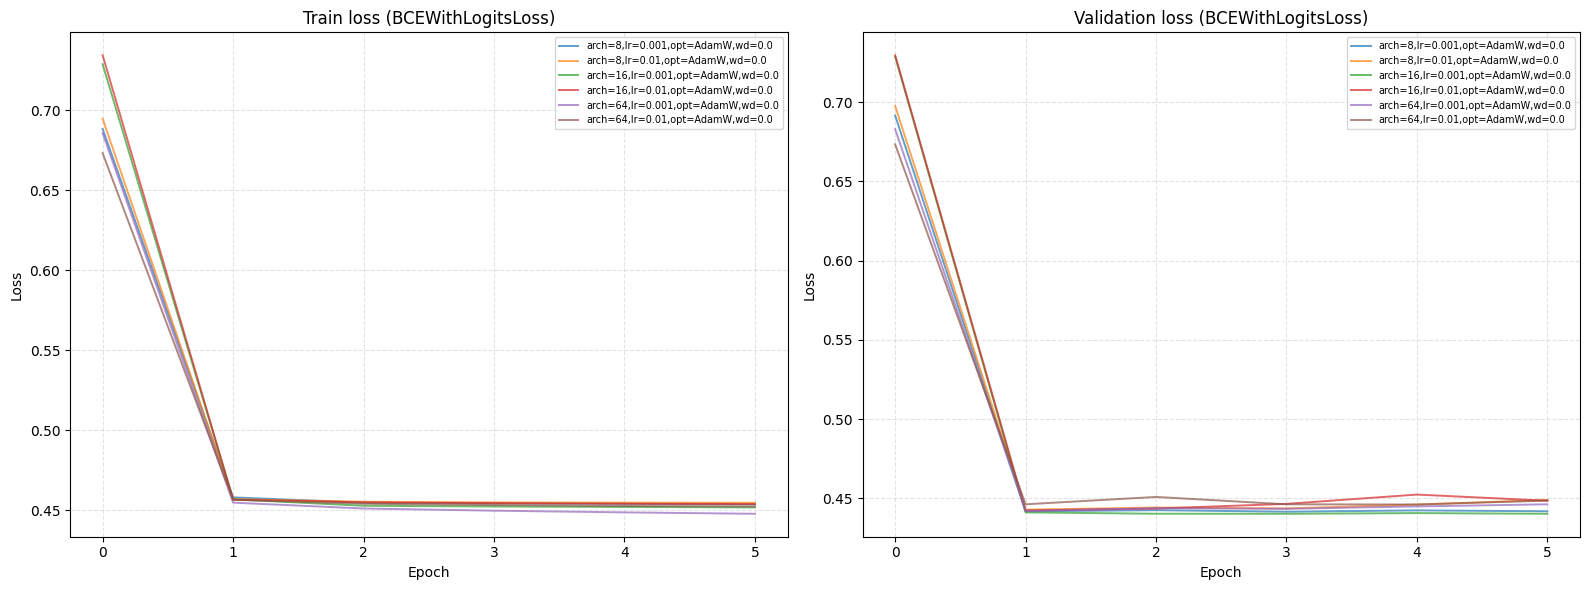

In [11]:
# Showed that training loss decreases while val loss increases. Overparametrization is likely and we need weight decay
# ── Run ────────────────────────────────────────────────────────────────────────
jobs   = [(arch, lr, opt, wd) for arch in architectures for lr in learning_rates for opt in optimizer_names for wd in weight_decays]
n_jobs = N_JOBS if N_JOBS is not None else max(1, min(len(jobs), (os.cpu_count() or 2) - 1))
print(f"Running {len(jobs)} combos with {n_jobs} parallel workers (CPU count={os.cpu_count()})")

results = Parallel(n_jobs=n_jobs, prefer="processes", verbose=0)(
    delayed(_train_combo)(
        X_train, y_train, X_val, y_val,
        arch, lr, opt, wd, num_epochs, batch_size
    )
    for arch, lr, opt, wd in jobs
)
experiment_losses = dict(results)
print("Done.")

# ── Brier score summary (lower = better) ──────────────────────────────────────
ranked = sorted(experiment_losses.items(), key=lambda kv: kv[1]["val_brier"])
col = 12
header = f"{'Rank':<6} {'Val Brier':>10}  Key"
print(f"\n{header}")
print("-" * (len(header) + col))
for rank, (key, losses) in enumerate(ranked, 1):
    print(f"{rank:<6} {losses['val_brier']:>10.6f}  {key}")
print()


# One plot for all training losses
# ── Plots ──────────────────────────────────────────────────────────────────────
epochs_ax = np.arange(0, num_epochs + 1)  # 0 = random init baseline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for key, losses in experiment_losses.items():
    axes[0].plot(epochs_ax, losses["train_losses"], alpha=0.7, linewidth=1.4, label=key)
    axes[1].plot(epochs_ax, losses["val_losses"],   alpha=0.7, linewidth=1.4, label=key)

for ax, title in zip(axes, ["Train loss (BCEWithLogitsLoss)", "Validation loss (BCEWithLogitsLoss)"]):
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [14]:
# Showed that smaller architectures were better
architectures  = [[8], [16], [32], [64], [128], [256], [512]]   # single-layer networks: 8, 16, 32, 64 hidden units
learning_rates = [1e-3]
optimizer_names = ["AdamW"]           # any subset of: "AdamW", "sgd", "rmsprop"
weight_decays  = [0.0, 1e-2, 1e-4]               # e.g. [0.0, 1e-4, 1e-3]
num_epochs     = 5
batch_size     = 64
N_JOBS         = 6   

jobs   = [(arch, lr, opt, wd) for arch in architectures for lr in learning_rates for opt in optimizer_names for wd in weight_decays]
n_jobs = N_JOBS if N_JOBS is not None else max(1, min(len(jobs), (os.cpu_count() or 2) - 1))
print(f"Running {len(jobs)} combos with {n_jobs} parallel workers (CPU count={os.cpu_count()})")

results = Parallel(n_jobs=n_jobs, prefer="processes", verbose=0)(
    delayed(_train_combo)(
        X_train, y_train, X_val, y_val,
        arch, lr, opt, wd, num_epochs, batch_size
    )
    for arch, lr, opt, wd in jobs
)
experiment_losses = dict(results)
print("Done.")

Running 21 combos with 6 parallel workers (CPU count=12)


c:\Users\rajak\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Done.


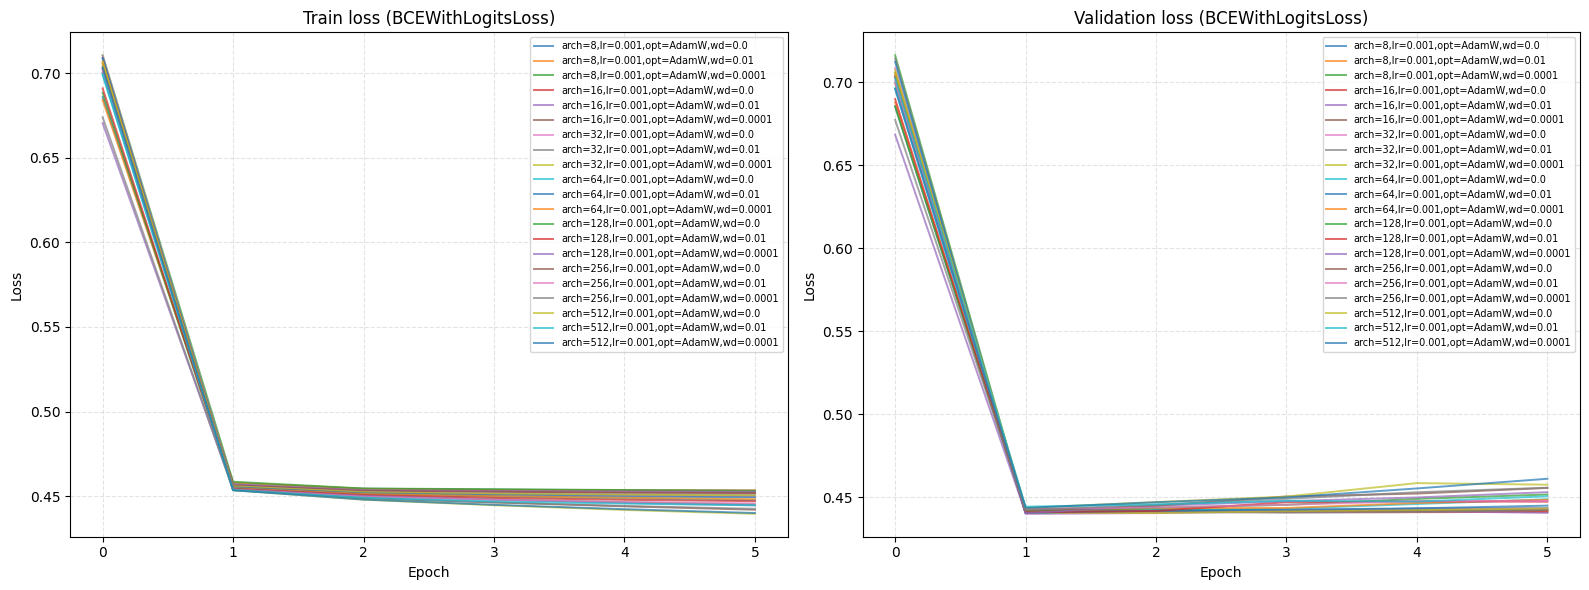

In [15]:


# One plot for all training losses
# ── Plots ──────────────────────────────────────────────────────────────────────
epochs_ax = np.arange(0, num_epochs + 1)  # 0 = random init baseline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for key, losses in experiment_losses.items():
    axes[0].plot(epochs_ax, losses["train_losses"], alpha=0.7, linewidth=1.4, label=key)
    axes[1].plot(epochs_ax, losses["val_losses"],   alpha=0.7, linewidth=1.4, label=key)

for ax, title in zip(axes, ["Train loss (BCEWithLogitsLoss)", "Validation loss (BCEWithLogitsLoss)"]):
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


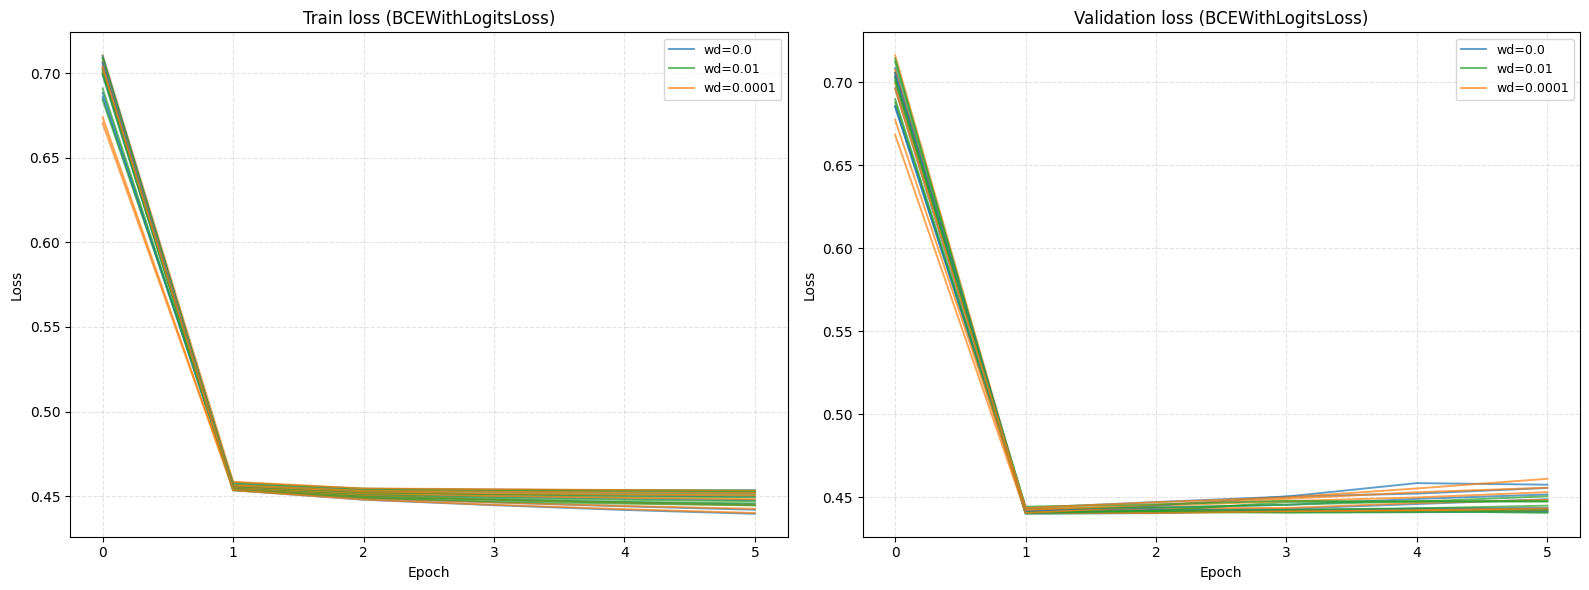

In [17]:
# ── Plots grouped and colored by weight decay ────────────────────────────────
epochs_ax = np.arange(0, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# collect unique weight decays
unique_wd = sorted({
    key.split("wd=")[-1]
    for key in experiment_losses
})

# assign one color per weight decay
cmap = plt.cm.tab10
wd_to_color = {
    wd: cmap(i % 10)
    for i, wd in enumerate(unique_wd)
}

seen_wd = set()

for key, losses in experiment_losses.items():
    wd = key.split("wd=")[-1]
    color = wd_to_color[wd]

    label = f"wd={wd}" if wd not in seen_wd else None
    seen_wd.add(wd)

    axes[0].plot(
        epochs_ax,
        losses["train_losses"],
        color=color,
        alpha=0.7,
        linewidth=1.4,
        label=label
    )

    axes[1].plot(
        epochs_ax,
        losses["val_losses"],
        color=color,
        alpha=0.7,
        linewidth=1.4,
        label=label
    )

for ax, title in zip(
    axes,
    [
        "Train loss (BCEWithLogitsLoss)",
        "Validation loss (BCEWithLogitsLoss)"
    ]
):
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
import torch
import torch.nn as nn

# Instantiate a fresh (randomly initialized) model with the same arch you're testing
_check_model = MLP(X_train.shape[1], hidden_layers=[64])  # change hidden_layers as needed
_criterion   = nn.BCEWithLogitsLoss()

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

with torch.no_grad():
    logits    = _check_model(X_val_t)
    init_loss = _criterion(logits, y_val_t.view(-1, 1)).item()

    val_probs  = torch.sigmoid(logits).view(-1)
    init_brier = ((val_probs - y_val_t.view(-1)) ** 2).mean().item()

print(f"Initial val BCE loss : {init_loss:.6f}")
print(f"Initial val Brier    : {init_brier:.6f}")

Initial val BCE loss : 0.715963
Initial val Brier    : 0.261392


In [19]:
# 16 and 8 hidden units worked best
# ── Rank by final validation BCE loss (lower = better) ────────────────────────
ranked_bce = sorted(experiment_losses.items(), key=lambda kv: kv[1]["val_losses"][-1])
print(f"{'Rank':<6} {'Final Val BCE':>14}  Key")
print("-" * 70)
for rank, (key, losses) in enumerate(ranked_bce, 1):
    print(f"{rank:<6} {losses['val_losses'][-1]:>14.6f}  {key}")

Rank    Final Val BCE  Key
----------------------------------------------------------------------
1            0.440446  arch=16,lr=0.001,opt=AdamW,wd=0.01
2            0.441069  arch=16,lr=0.001,opt=AdamW,wd=0.0
3            0.441465  arch=8,lr=0.001,opt=AdamW,wd=0.01
4            0.442160  arch=16,lr=0.001,opt=AdamW,wd=0.0001
5            0.442189  arch=32,lr=0.001,opt=AdamW,wd=0.01
6            0.442206  arch=8,lr=0.001,opt=AdamW,wd=0.0001
7            0.443097  arch=32,lr=0.001,opt=AdamW,wd=0.0
8            0.443166  arch=32,lr=0.001,opt=AdamW,wd=0.0001
9            0.443282  arch=8,lr=0.001,opt=AdamW,wd=0.0
10           0.444815  arch=64,lr=0.001,opt=AdamW,wd=0.01
11           0.447207  arch=128,lr=0.001,opt=AdamW,wd=0.01
12           0.447604  arch=256,lr=0.001,opt=AdamW,wd=0.01
13           0.448366  arch=64,lr=0.001,opt=AdamW,wd=0.0001
14           0.448659  arch=64,lr=0.001,opt=AdamW,wd=0.0
15           0.450458  arch=512,lr=0.001,opt=AdamW,wd=0.01
16           0.451540  arch=

In [20]:
# ── Rank by final validation Brier score (lower = better) ─────────────────────
ranked_brier = sorted(experiment_losses.items(), key=lambda kv: kv[1]["val_brier"])
print(f"{'Rank':<6} {'Val Brier':>10}  Key")
print("-" * 70)
for rank, (key, losses) in enumerate(ranked_brier, 1):
    print(f"{rank:<6} {losses['val_brier']:>10.6f}  {key}")

Rank    Val Brier  Key
----------------------------------------------------------------------
1        0.146411  arch=16,lr=0.001,opt=AdamW,wd=0.01
2        0.146655  arch=8,lr=0.001,opt=AdamW,wd=0.01
3        0.146687  arch=16,lr=0.001,opt=AdamW,wd=0.0
4        0.146816  arch=8,lr=0.001,opt=AdamW,wd=0.0
5        0.146909  arch=8,lr=0.001,opt=AdamW,wd=0.0001
6        0.146961  arch=16,lr=0.001,opt=AdamW,wd=0.0001
7        0.147250  arch=32,lr=0.001,opt=AdamW,wd=0.01
8        0.147354  arch=32,lr=0.001,opt=AdamW,wd=0.0
9        0.147540  arch=64,lr=0.001,opt=AdamW,wd=0.01
10       0.147557  arch=32,lr=0.001,opt=AdamW,wd=0.0001
11       0.148001  arch=64,lr=0.001,opt=AdamW,wd=0.0001
12       0.148424  arch=128,lr=0.001,opt=AdamW,wd=0.01
13       0.148525  arch=64,lr=0.001,opt=AdamW,wd=0.0
14       0.148628  arch=256,lr=0.001,opt=AdamW,wd=0.01
15       0.149239  arch=512,lr=0.001,opt=AdamW,wd=0.01
16       0.149584  arch=128,lr=0.001,opt=AdamW,wd=0.0
17       0.149968  arch=128,lr=0.001,o

In [21]:
architectures  = [[8]]   # single-layer networks: 8, 16, 32, 64 hidden units
learning_rates = [1e-2]
optimizer_names = ["AdamW"]           # any subset of: "AdamW", "sgd", "rmsprop"
weight_decays  = [0.0]               # e.g. [0.0, 1e-4, 1e-3]
num_epochs     = 5
batch_size     = 64
N_JOBS         = 1   

jobs   = [(arch, lr, opt, wd) for arch in architectures for lr in learning_rates for opt in optimizer_names for wd in weight_decays]
n_jobs = N_JOBS if N_JOBS is not None else max(1, min(len(jobs), (os.cpu_count() or 2) - 1))
print(f"Running {len(jobs)} combos with {n_jobs} parallel workers (CPU count={os.cpu_count()})")

results = Parallel(n_jobs=n_jobs, prefer="processes", verbose=0)(
    delayed(_train_combo)(
        X_train, y_train, X_val, y_val,
        arch, lr, opt, wd, num_epochs, batch_size
    )
    for arch, lr, opt, wd in jobs
)
experiment_losses = dict(results)
print("Done.")

Running 1 combos with 1 parallel workers (CPU count=12)
[DEBUG] worker received weight_decay=0.0, optimizer=AdamW
epoch 1/5 (arch=8,lr=0.01,opt=AdamW,wd=0.0) train=0.457055  val=0.440768
epoch 2/5 (arch=8,lr=0.01,opt=AdamW,wd=0.0) train=0.455283  val=0.441051
epoch 3/5 (arch=8,lr=0.01,opt=AdamW,wd=0.0) train=0.454853  val=0.443307
epoch 4/5 (arch=8,lr=0.01,opt=AdamW,wd=0.0) train=0.454610  val=0.442768
epoch 5/5 (arch=8,lr=0.01,opt=AdamW,wd=0.0) train=0.454540  val=0.440406
Done.


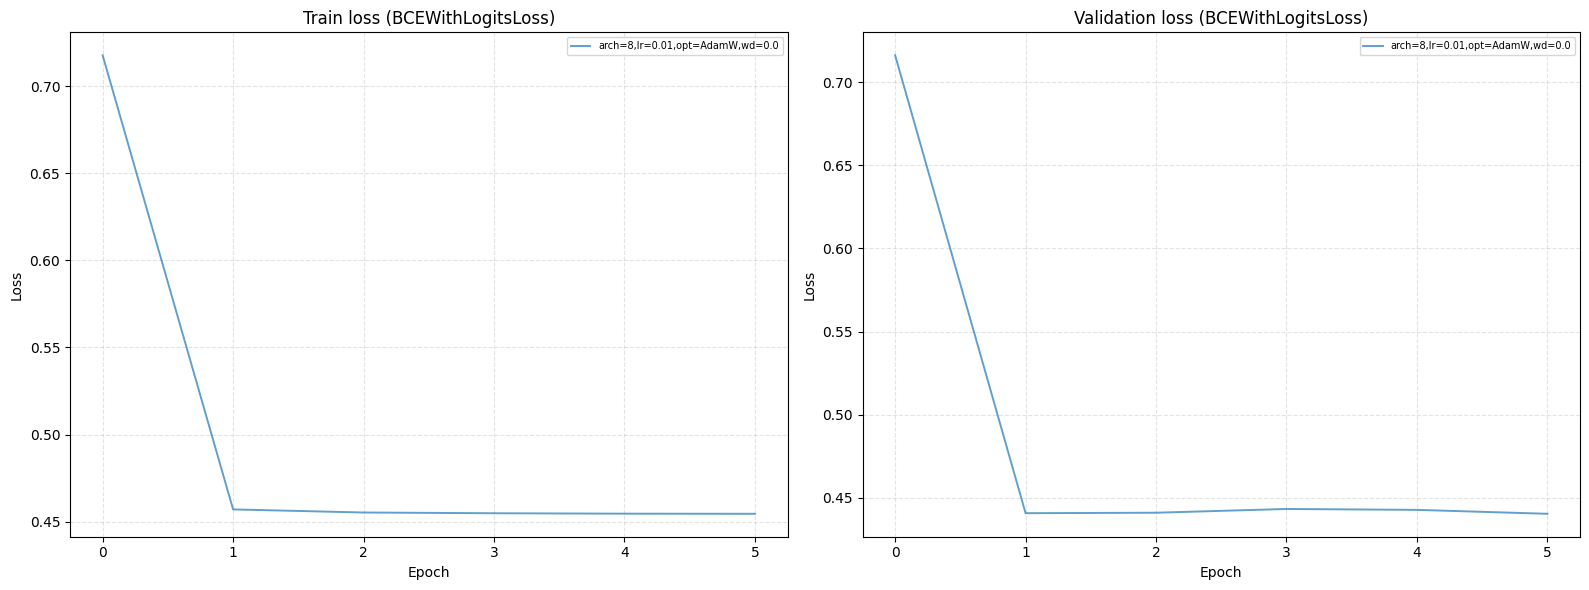

In [23]:
# One plot for all training losses
# ── Plots ──────────────────────────────────────────────────────────────────────
epochs_ax = np.arange(0, num_epochs + 1)  # 0 = random init baseline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for key, losses in experiment_losses.items():
    axes[0].plot(epochs_ax, losses["train_losses"], alpha=0.7, linewidth=1.4, label=key)
    axes[1].plot(epochs_ax, losses["val_losses"],   alpha=0.7, linewidth=1.4, label=key)

for ax, title in zip(axes, ["Train loss (BCEWithLogitsLoss)", "Validation loss (BCEWithLogitsLoss)"]):
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [24]:
architectures  = [[8], [16], [64], [16, 16], [16, 8], [8, 8]] 
learning_rates = [0.01, 0.1]
optimizer_names = ["AdamW"]           # any subset of: "AdamW", "sgd", "rmsprop"
weight_decays  = [0.0]               # e.g. [0.0, 1e-4, 1e-3]
num_epochs     = 5
batch_size     = 256
N_JOBS         = 6   

jobs   = [(arch, lr, opt, wd) for arch in architectures for lr in learning_rates for opt in optimizer_names for wd in weight_decays]
n_jobs = N_JOBS if N_JOBS is not None else max(1, min(len(jobs), (os.cpu_count() or 2) - 1))
print(f"Running {len(jobs)} combos with {n_jobs} parallel workers (CPU count={os.cpu_count()})")

results = Parallel(n_jobs=n_jobs, prefer="processes", verbose=0)(
    delayed(_train_combo)(
        X_train, y_train, X_val, y_val,
        arch, lr, opt, wd, num_epochs, batch_size
    )
    for arch, lr, opt, wd in jobs
)
experiment_losses = dict(results)
print("Done.")

Running 12 combos with 6 parallel workers (CPU count=12)
Done.


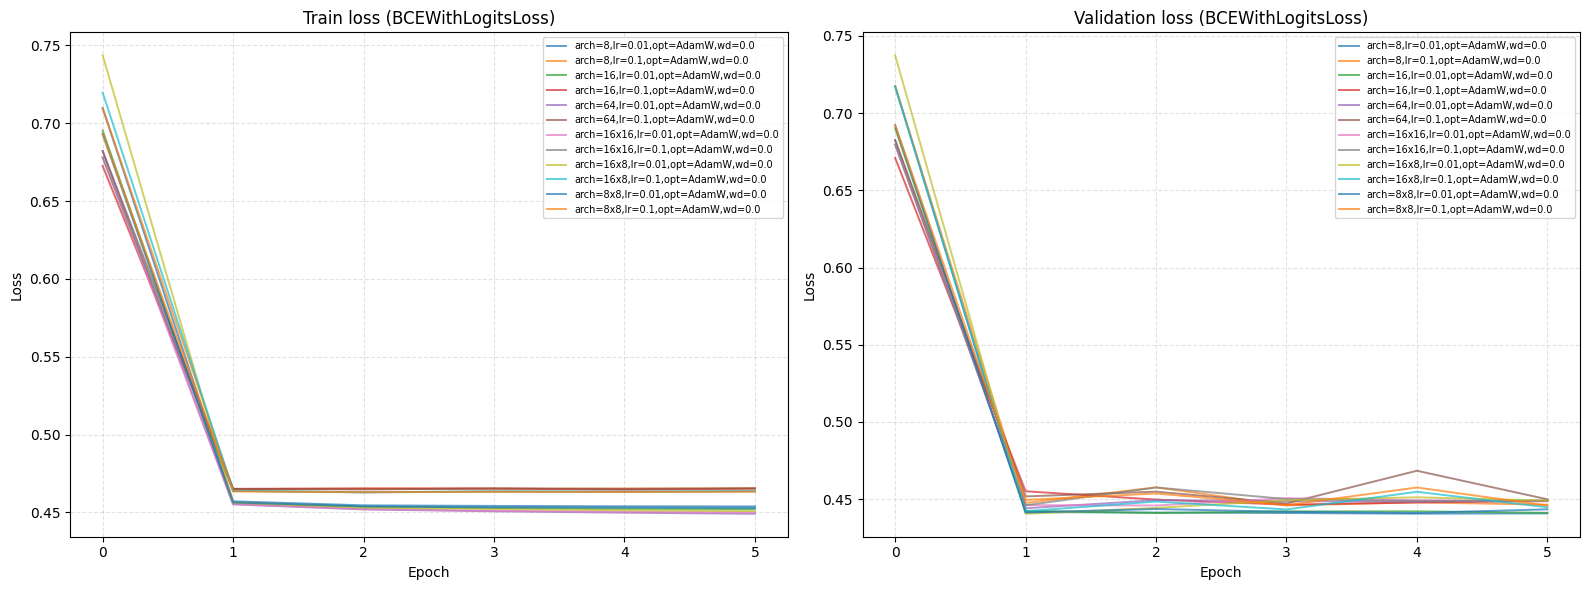

In [25]:
# One plot for all training losses
# ── Plots ──────────────────────────────────────────────────────────────────────
epochs_ax = np.arange(0, num_epochs + 1)  # 0 = random init baseline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for key, losses in experiment_losses.items():
    axes[0].plot(epochs_ax, losses["train_losses"], alpha=0.7, linewidth=1.4, label=key)
    axes[1].plot(epochs_ax, losses["val_losses"],   alpha=0.7, linewidth=1.4, label=key)

for ax, title in zip(axes, ["Train loss (BCEWithLogitsLoss)", "Validation loss (BCEWithLogitsLoss)"]):
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [26]:
# ── Rank by final validation BCE loss (lower = better) ────────────────────────
ranked_bce = sorted(experiment_losses.items(), key=lambda kv: kv[1]["val_losses"][-1])
print(f"{'Rank':<6} {'Final Val BCE':>14}  Key")
print("-" * 70)
for rank, (key, losses) in enumerate(ranked_bce, 1):
    print(f"{rank:<6} {losses['val_losses'][-1]:>14.6f}  {key}")

Rank    Final Val BCE  Key
----------------------------------------------------------------------
1            0.440765  arch=8,lr=0.01,opt=AdamW,wd=0.0
2            0.441131  arch=16,lr=0.01,opt=AdamW,wd=0.0
3            0.443400  arch=8x8,lr=0.01,opt=AdamW,wd=0.0
4            0.444707  arch=16x8,lr=0.1,opt=AdamW,wd=0.0
5            0.445795  arch=8x8,lr=0.1,opt=AdamW,wd=0.0
6            0.446395  arch=8,lr=0.1,opt=AdamW,wd=0.0
7            0.448569  arch=16x16,lr=0.01,opt=AdamW,wd=0.0
8            0.448795  arch=16,lr=0.1,opt=AdamW,wd=0.0
9            0.448997  arch=64,lr=0.01,opt=AdamW,wd=0.0
10           0.449030  arch=16x16,lr=0.1,opt=AdamW,wd=0.0
11           0.449037  arch=16x8,lr=0.01,opt=AdamW,wd=0.0
12           0.449887  arch=64,lr=0.1,opt=AdamW,wd=0.0


In [27]:
# ── Rank by final validation Brier score (lower = better) ─────────────────────
ranked_brier = sorted(experiment_losses.items(), key=lambda kv: kv[1]["val_brier"])
print(f"{'Rank':<6} {'Val Brier':>10}  Key")
print("-" * 70)
for rank, (key, losses) in enumerate(ranked_brier, 1):
    print(f"{rank:<6} {losses['val_brier']:>10.6f}  {key}")

Rank    Val Brier  Key
----------------------------------------------------------------------
1        0.146478  arch=8,lr=0.01,opt=AdamW,wd=0.0
2        0.146750  arch=16,lr=0.01,opt=AdamW,wd=0.0
3        0.147278  arch=8x8,lr=0.01,opt=AdamW,wd=0.0
4        0.147618  arch=16x16,lr=0.01,opt=AdamW,wd=0.0
5        0.147677  arch=8,lr=0.1,opt=AdamW,wd=0.0
6        0.148026  arch=16x8,lr=0.01,opt=AdamW,wd=0.0
7        0.148095  arch=16x8,lr=0.1,opt=AdamW,wd=0.0
8        0.148559  arch=8x8,lr=0.1,opt=AdamW,wd=0.0
9        0.148601  arch=16,lr=0.1,opt=AdamW,wd=0.0
10       0.148653  arch=64,lr=0.01,opt=AdamW,wd=0.0
11       0.148673  arch=16x16,lr=0.1,opt=AdamW,wd=0.0
12       0.148883  arch=64,lr=0.1,opt=AdamW,wd=0.0


Use a learning rate of 0.01

In [28]:
architectures  = [[8], [16], [64], [16, 16], [16, 8], [8, 8]] 
learning_rates = [0.01]
optimizer_names = ["AdamW"]           # any subset of: "AdamW", "sgd", "rmsprop"
weight_decays  = [0.0, 0.001, 0.01, 0.1, 1]               # e.g. [0.0, 1e-4, 1e-3]
num_epochs     = 5
batch_size     = 2048
N_JOBS         = 6   

jobs   = [(arch, lr, opt, wd) for arch in architectures for lr in learning_rates for opt in optimizer_names for wd in weight_decays]
n_jobs = N_JOBS if N_JOBS is not None else max(1, min(len(jobs), (os.cpu_count() or 2) - 1))
print(f"Running {len(jobs)} combos with {n_jobs} parallel workers (CPU count={os.cpu_count()})")

results = Parallel(n_jobs=n_jobs, prefer="processes", verbose=0)(
    delayed(_train_combo)(
        X_train, y_train, X_val, y_val,
        arch, lr, opt, wd, num_epochs, batch_size
    )
    for arch, lr, opt, wd in jobs
)
experiment_losses = dict(results)
print("Done.")

Running 30 combos with 6 parallel workers (CPU count=12)


c:\Users\rajak\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Done.


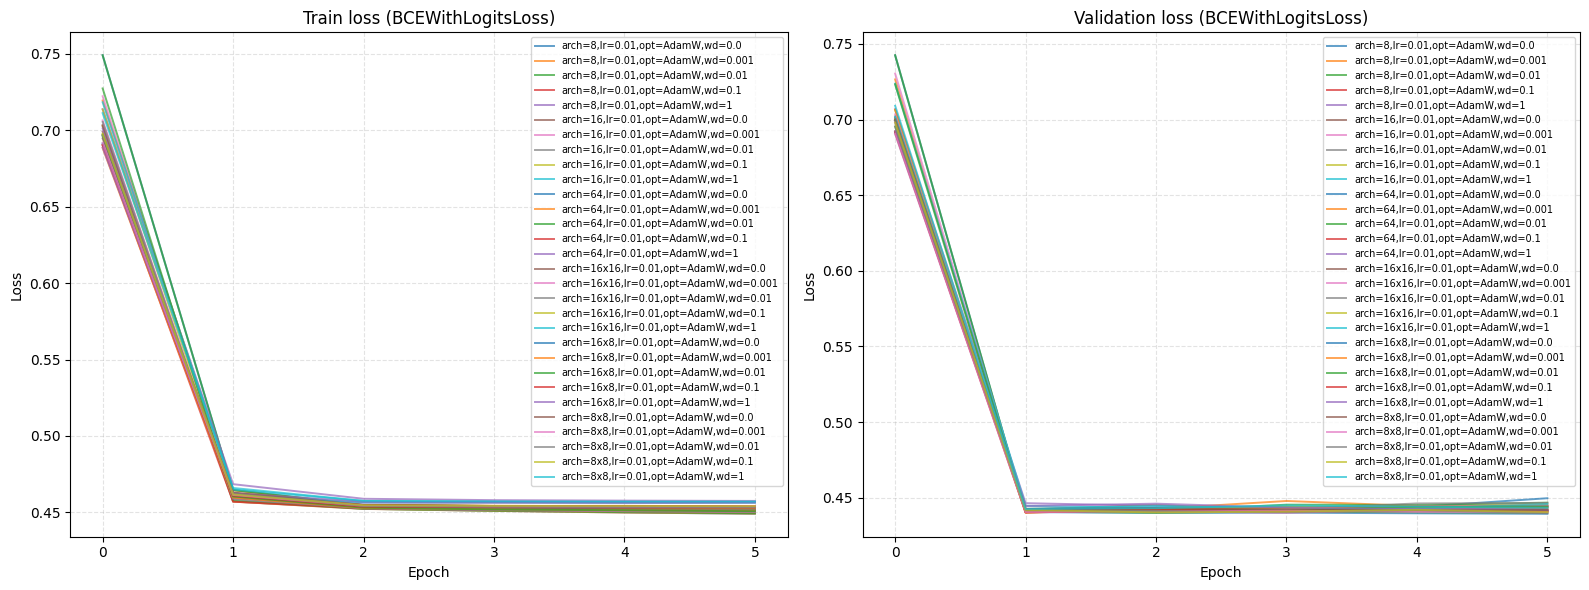

In [29]:
# One plot for all training losses
# ── Plots ──────────────────────────────────────────────────────────────────────
epochs_ax = np.arange(0, num_epochs + 1)  # 0 = random init baseline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for key, losses in experiment_losses.items():
    axes[0].plot(epochs_ax, losses["train_losses"], alpha=0.7, linewidth=1.4, label=key)
    axes[1].plot(epochs_ax, losses["val_losses"],   alpha=0.7, linewidth=1.4, label=key)

for ax, title in zip(axes, ["Train loss (BCEWithLogitsLoss)", "Validation loss (BCEWithLogitsLoss)"]):
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [30]:
# ── Rank by final validation BCE loss (lower = better) ────────────────────────
ranked_bce = sorted(experiment_losses.items(), key=lambda kv: kv[1]["val_losses"][-1])
print(f"{'Rank':<6} {'Final Val BCE':>14}  Key")
print("-" * 70)
for rank, (key, losses) in enumerate(ranked_bce, 1):
    print(f"{rank:<6} {losses['val_losses'][-1]:>14.6f}  {key}")

Rank    Final Val BCE  Key
----------------------------------------------------------------------
1            0.439412  arch=8,lr=0.01,opt=AdamW,wd=0.0
2            0.439770  arch=8x8,lr=0.01,opt=AdamW,wd=0.01
3            0.440040  arch=8,lr=0.01,opt=AdamW,wd=0.01
4            0.440309  arch=8x8,lr=0.01,opt=AdamW,wd=0.001
5            0.440579  arch=8x8,lr=0.01,opt=AdamW,wd=0.1
6            0.440810  arch=16,lr=0.01,opt=AdamW,wd=0.1
7            0.440911  arch=16x8,lr=0.01,opt=AdamW,wd=0.1
8            0.441196  arch=64,lr=0.01,opt=AdamW,wd=0.1
9            0.441351  arch=16,lr=0.01,opt=AdamW,wd=0.0
10           0.441557  arch=16x8,lr=0.01,opt=AdamW,wd=0.0
11           0.441682  arch=16,lr=0.01,opt=AdamW,wd=0.001
12           0.441712  arch=8,lr=0.01,opt=AdamW,wd=0.001
13           0.441972  arch=64,lr=0.01,opt=AdamW,wd=1
14           0.442041  arch=8x8,lr=0.01,opt=AdamW,wd=0.0
15           0.442109  arch=16x8,lr=0.01,opt=AdamW,wd=1
16           0.442223  arch=16x16,lr=0.01,opt=AdamW

In [31]:
# ── Rank by final validation Brier score (lower = better) ─────────────────────
ranked_brier = sorted(experiment_losses.items(), key=lambda kv: kv[1]["val_brier"])
print(f"{'Rank':<6} {'Val Brier':>10}  Key")
print("-" * 70)
for rank, (key, losses) in enumerate(ranked_brier, 1):
    print(f"{rank:<6} {losses['val_brier']:>10.6f}  {key}")

Rank    Val Brier  Key
----------------------------------------------------------------------
1        0.146227  arch=8,lr=0.01,opt=AdamW,wd=0.0
2        0.146290  arch=8x8,lr=0.01,opt=AdamW,wd=0.01
3        0.146385  arch=8,lr=0.01,opt=AdamW,wd=0.01
4        0.146475  arch=8x8,lr=0.01,opt=AdamW,wd=0.1
5        0.146511  arch=8x8,lr=0.01,opt=AdamW,wd=0.001
6        0.146608  arch=8,lr=0.01,opt=AdamW,wd=0.001
7        0.146656  arch=16x8,lr=0.01,opt=AdamW,wd=0.0
8        0.146662  arch=16,lr=0.01,opt=AdamW,wd=0.0
9        0.146664  arch=16,lr=0.01,opt=AdamW,wd=0.1
10       0.146685  arch=16x8,lr=0.01,opt=AdamW,wd=0.1
11       0.146731  arch=16x8,lr=0.01,opt=AdamW,wd=1
12       0.146801  arch=64,lr=0.01,opt=AdamW,wd=0.1
13       0.146840  arch=8,lr=0.01,opt=AdamW,wd=0.1
14       0.146925  arch=64,lr=0.01,opt=AdamW,wd=1
15       0.146988  arch=16,lr=0.01,opt=AdamW,wd=1
16       0.146988  arch=16,lr=0.01,opt=AdamW,wd=0.01
17       0.147065  arch=8x8,lr=0.01,opt=AdamW,wd=1
18       0.147073

In [44]:
architectures  = [[8], [16]] 
learning_rates = [1, 0.1, 0.01, 0.001, 0.0001]
optimizer_names = ["AdamW"]           # any subset of: "AdamW", "sgd", "rmsprop"
weight_decays  = [0.0, 0.001, 0.01, 0.1, 1]               # e.g. [0.0, 1e-4, 1e-3]
num_epochs     = 10
batch_size     = 16384
N_JOBS         = 5   

jobs   = [(arch, lr, opt, wd) for arch in architectures for lr in learning_rates for opt in optimizer_names for wd in weight_decays]
n_jobs = N_JOBS if N_JOBS is not None else max(1, min(len(jobs), (os.cpu_count() or 2) - 1))
print(f"Running {len(jobs)} combos with {n_jobs} parallel workers (CPU count={os.cpu_count()})")

results = Parallel(n_jobs=n_jobs, prefer="processes", verbose=0)(
    delayed(_train_combo)(
        X_train, y_train, X_val, y_val,
        arch, lr, opt, wd, num_epochs, batch_size
    )
    for arch, lr, opt, wd in jobs
)
experiment_losses = dict(results)
print("Done.")

Running 50 combos with 5 parallel workers (CPU count=12)
Done.


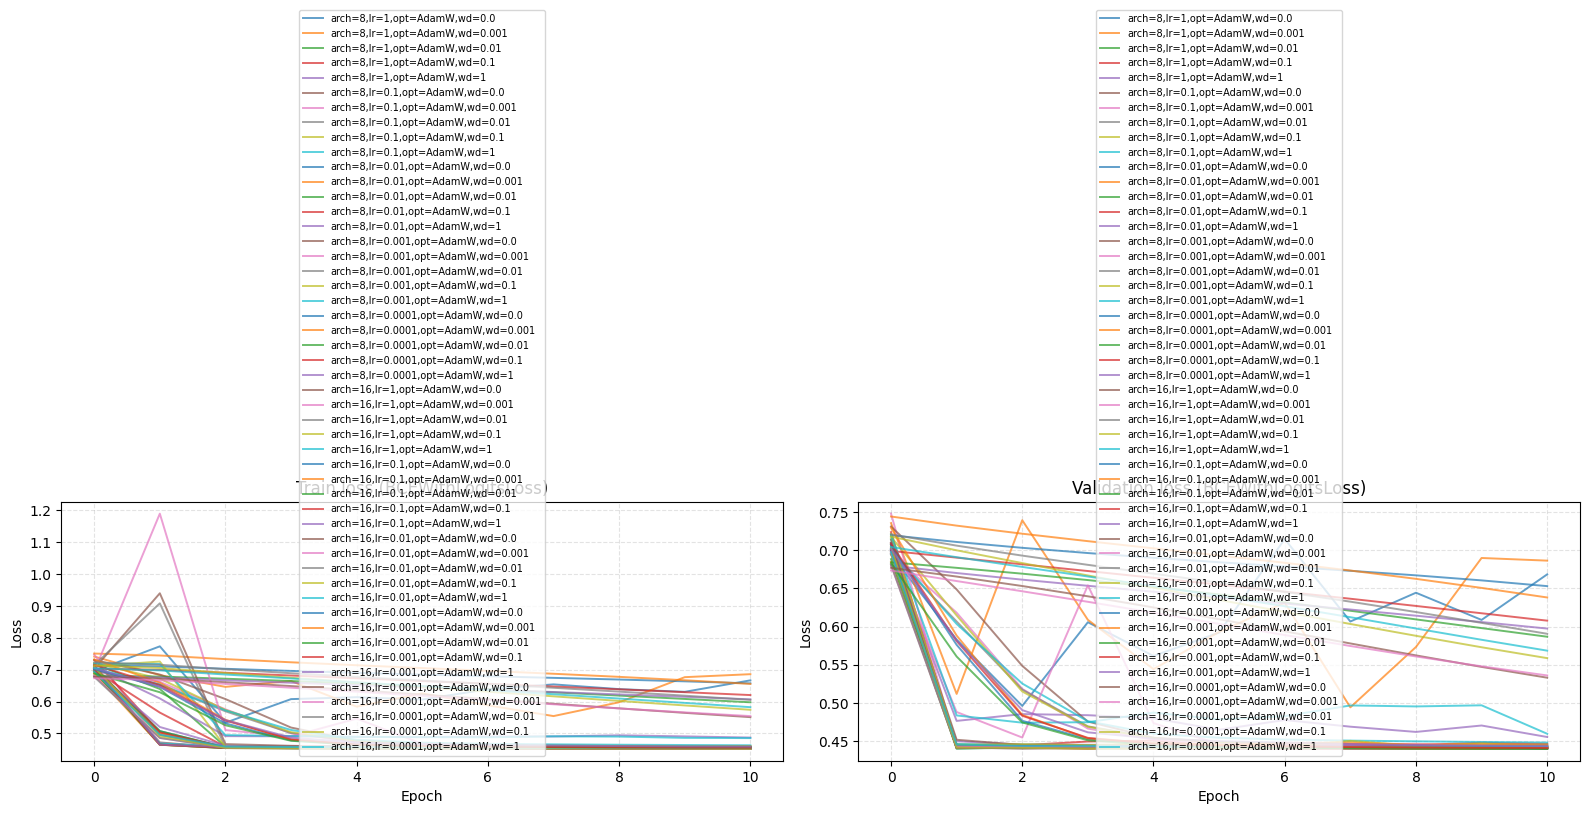

In [45]:
# One plot for all training losses
# ── Plots ──────────────────────────────────────────────────────────────────────
epochs_ax = np.arange(0, num_epochs + 1)  # 0 = random init baseline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for key, losses in experiment_losses.items():
    axes[0].plot(epochs_ax, losses["train_losses"], alpha=0.7, linewidth=1.4, label=key)
    axes[1].plot(epochs_ax, losses["val_losses"],   alpha=0.7, linewidth=1.4, label=key)

for ax, title in zip(axes, ["Train loss (BCEWithLogitsLoss)", "Validation loss (BCEWithLogitsLoss)"]):
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

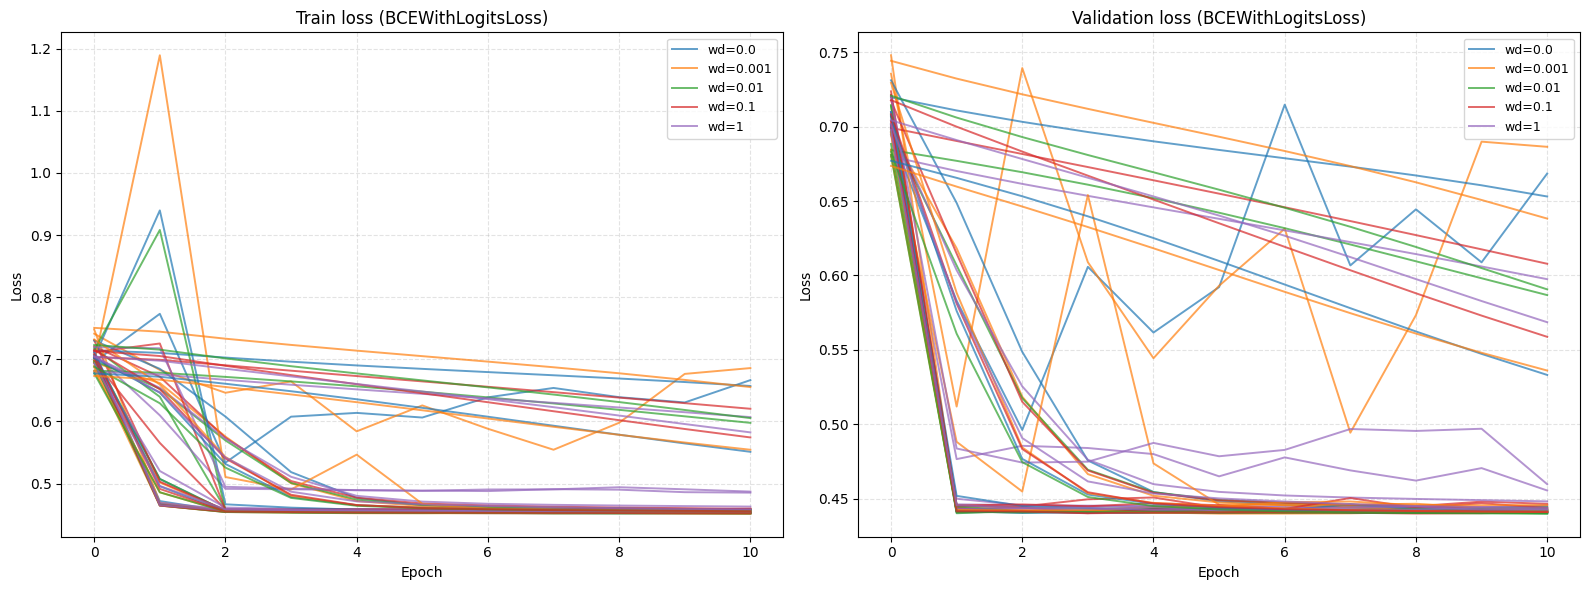

In [46]:
# ── Plots grouped and colored by weight decay ────────────────────────────────
epochs_ax = np.arange(0, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# collect unique weight decays
unique_wd = sorted({
    key.split("wd=")[-1]
    for key in experiment_losses
})

# assign one color per weight decay
cmap = plt.cm.tab10
wd_to_color = {
    wd: cmap(i % 10)
    for i, wd in enumerate(unique_wd)
}

seen_wd = set()

for key, losses in experiment_losses.items():
    wd = key.split("wd=")[-1]
    color = wd_to_color[wd]

    label = f"wd={wd}" if wd not in seen_wd else None
    seen_wd.add(wd)

    axes[0].plot(
        epochs_ax,
        losses["train_losses"],
        color=color,
        alpha=0.7,
        linewidth=1.4,
        label=label
    )

    axes[1].plot(
        epochs_ax,
        losses["val_losses"],
        color=color,
        alpha=0.7,
        linewidth=1.4,
        label=label
    )

for ax, title in zip(
    axes,
    [
        "Train loss (BCEWithLogitsLoss)",
        "Validation loss (BCEWithLogitsLoss)"
    ]
):
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

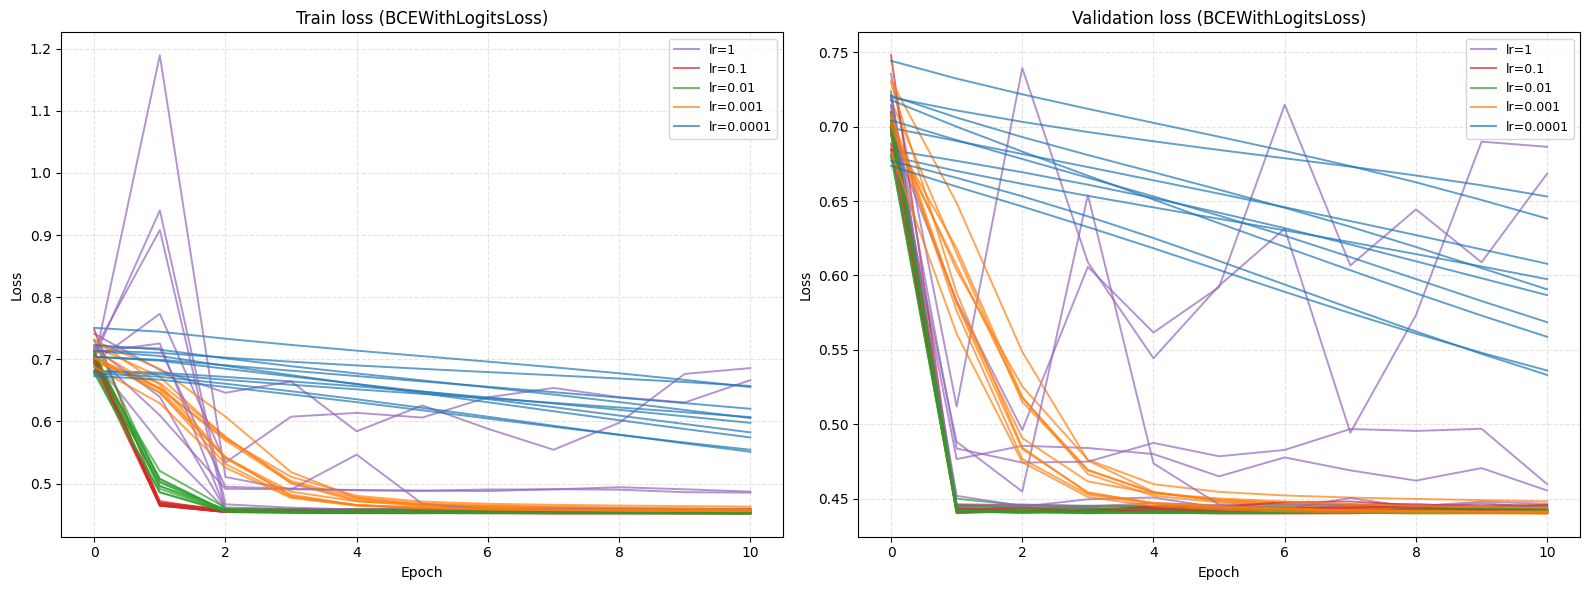

In [47]:
# ── Plots grouped and colored by learning rate ─────────────────────────────────
def param_from_key(key: str, name: str) -> str:
    prefix = f"{name}="
    for part in key.split(","):
        if part.startswith(prefix):
            return part[len(prefix) :]
    raise KeyError(f"{name} not in {key!r}")


epochs_ax = np.arange(0, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# collect unique learning rates (lr is not the last field in the key string)
unique_lr = sorted(
    {param_from_key(key, "lr") for key in experiment_losses},
    key=float,
)

# assign one color per learning rate
cmap = plt.cm.tab10
lr_to_color = {lr: cmap(i % 10) for i, lr in enumerate(unique_lr)}

seen_lr = set()

for key, losses in experiment_losses.items():
    lr = param_from_key(key, "lr")
    color = lr_to_color[lr]

    label = f"lr={lr}" if lr not in seen_lr else None
    seen_lr.add(lr)

    axes[0].plot(
        epochs_ax,
        losses["train_losses"],
        color=color,
        alpha=0.7,
        linewidth=1.4,
        label=label
    )

    axes[1].plot(
        epochs_ax,
        losses["val_losses"],
        color=color,
        alpha=0.7,
        linewidth=1.4,
        label=label
    )

for ax, title in zip(
    axes,
    [
        "Train loss (BCEWithLogitsLoss)",
        "Validation loss (BCEWithLogitsLoss)"
    ]
):
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [48]:
# ── Rank by final validation BCE loss (lower = better) ────────────────────────
ranked_bce = sorted(experiment_losses.items(), key=lambda kv: kv[1]["val_losses"][-1])
print(f"{'Rank':<6} {'Final Val BCE':>14}  Key")
print("-" * 70)
for rank, (key, losses) in enumerate(ranked_bce, 1):
    print(f"{rank:<6} {losses['val_losses'][-1]:>14.6f}  {key}")

Rank    Final Val BCE  Key
----------------------------------------------------------------------
1            0.439723  arch=16,lr=0.001,opt=AdamW,wd=0.01
2            0.440107  arch=8,lr=0.1,opt=AdamW,wd=0.0
3            0.440110  arch=16,lr=0.01,opt=AdamW,wd=0.01
4            0.440291  arch=16,lr=1,opt=AdamW,wd=0.0
5            0.440419  arch=8,lr=0.01,opt=AdamW,wd=0.0
6            0.440535  arch=8,lr=1,opt=AdamW,wd=0.01
7            0.440828  arch=16,lr=0.001,opt=AdamW,wd=0.001
8            0.440879  arch=8,lr=0.1,opt=AdamW,wd=0.01
9            0.440903  arch=16,lr=0.001,opt=AdamW,wd=0.1
10           0.440910  arch=8,lr=0.01,opt=AdamW,wd=0.001
11           0.440955  arch=8,lr=0.01,opt=AdamW,wd=0.1
12           0.441018  arch=8,lr=0.1,opt=AdamW,wd=0.001
13           0.441027  arch=16,lr=0.1,opt=AdamW,wd=0.0
14           0.441089  arch=16,lr=0.01,opt=AdamW,wd=0.1
15           0.441238  arch=8,lr=0.1,opt=AdamW,wd=0.1
16           0.441280  arch=16,lr=0.001,opt=AdamW,wd=0.0
17         

In [49]:
# ── Rank by final validation Brier score (lower = better) ─────────────────────
ranked_brier = sorted(experiment_losses.items(), key=lambda kv: kv[1]["val_brier"])
print(f"{'Rank':<6} {'Val Brier':>10}  Key")
print("-" * 70)
for rank, (key, losses) in enumerate(ranked_brier, 1):
    print(f"{rank:<6} {losses['val_brier']:>10.6f}  {key}")

Rank    Val Brier  Key
----------------------------------------------------------------------
1        0.146086  arch=16,lr=0.001,opt=AdamW,wd=0.01
2        0.146317  arch=16,lr=0.001,opt=AdamW,wd=0.001
3        0.146392  arch=16,lr=0.01,opt=AdamW,wd=0.01
4        0.146394  arch=8,lr=0.01,opt=AdamW,wd=0.0
5        0.146405  arch=8,lr=0.01,opt=AdamW,wd=0.1
6        0.146414  arch=16,lr=0.001,opt=AdamW,wd=0.1
7        0.146506  arch=8,lr=0.1,opt=AdamW,wd=0.0
8        0.146526  arch=8,lr=0.01,opt=AdamW,wd=0.001
9        0.146550  arch=16,lr=0.001,opt=AdamW,wd=0.0
10       0.146555  arch=8,lr=0.1,opt=AdamW,wd=0.01
11       0.146577  arch=8,lr=0.1,opt=AdamW,wd=0.1
12       0.146593  arch=16,lr=1,opt=AdamW,wd=0.0
13       0.146600  arch=8,lr=0.01,opt=AdamW,wd=0.01
14       0.146601  arch=16,lr=0.01,opt=AdamW,wd=0.1
15       0.146624  arch=8,lr=1,opt=AdamW,wd=0.01
16       0.146651  arch=16,lr=0.01,opt=AdamW,wd=0.0
17       0.146664  arch=16,lr=0.1,opt=AdamW,wd=0.1
18       0.146694  arch=8,l